# 2장 5강: A/B 테스트 핵심 메커니즘과 실험 설계 오류 식별 — 실습문제

## Intro

**과제 소개**
프로모션 A/B 데이터를 확인하고, 실험 결과를 신뢰하려면 어떤 조건을 점검해야 하는지 설명합니다. 교안의 개념을 이용해 **판단 → 사례 속 근거 → 이유 → 수정 방향**을 연결하는 것이 목표입니다.

**과제 목표**
- 대조군·실험군과 무작위 배정의 역할을 설명한다.
- 분석 단위·기간·핵심 지표·표본 크기를 구분한다.
- 신규성 효과·표본 오염·조기 종료·SRM을 사례의 근거로 진단한다.
- 핵심 지표와 중요한 보조 지표, 실험 조건을 함께 검토해 결론을 작성한다.

**구성**: 필수 1(중급 초입) → 필수 2(중급) → 과제 1(중급). **필수 1·2는 제출·채점 대상이 아니며, 과제 1만 제출·채점 대상**입니다.

**사용 툴/라이브러리**: Python, Jupyter Notebook, pandas, NumPy, matplotlib.

**학습 범위**: 판단에 필요한 개념은 교안의 1~4절을 사용합니다. 기본 pandas 집계·필터링은 기존 학습 내용을 활용하며, 새로운 통계 검정·표본 크기 계산·세그먼트 분석·수익 지표 설계는 요구하지 않습니다. 데이터 로딩과 그래프 코드는 제공합니다.

### 사용 데이터와 주요 컬럼

| 컬럼 | 의미 | 이번 실습에서의 사용 |
|---|---|---|
| LocationID | 매장 식별자 | 매장 수와 매장별 평균 계산 |
| Promotion | 프로모션 구분 | 1=A, 2=B로 가정; 3은 비교에서 제외 |
| week | 관측 주차 | 주차별 비교 |
| SalesInThousands | 천 단위로 기록된 매출 | 핵심 지표 계산 |
| MarketID / MarketSize / AgeOfStore | 시장·매장 특성 | 이번 실습에서는 분석하지 않음 |

### 분석에 필요한 설명 — 새로운 개념을 추론할 필요가 없도록 제공
- 실제 데이터는 `WA_Marketing-Campaign.csv`입니다. 같은 매장이 4주 동안 반복 기록되어 있습니다.
- 이 실습에서는 **매장을 배정·분석 단위**로 정합니다. 한 매장의 주차별 행이 여러 개여도 서로 다른 매장 여러 곳으로 세지 않습니다.
- 핵심 지표는 **매장별 4주 평균 주간 매출을 계산한 뒤, 그 값을 집단별로 평균한 값**입니다. 4주 누적 매출이 아닙니다.
- A는 기존 프로모션, B는 변경 프로모션이라는 **수업용 역할 가정**입니다. CSV가 실제 기존안·변경안을 알려주는 것은 아닙니다.
- 실제 배정 절차·예정 기간·목표 표본 수·예정 배정 비율은 CSV에 없습니다. 따라서 실제 데이터 문제와 별도로 **교육용 사례**의 조건을 명시합니다. 교육용 수치를 실제 WA 관측 결과와 섞지 않습니다.
- 무작위 배정은 각 대상이 정해진 확률로 배정되게 하는 절차입니다. 결과적인 집단 수가 반드시 같아야 한다는 뜻은 아닙니다.

### 파일 및 제출 안내
- 함께 제공된 실습문제·정답 및 해설 노트북과 기존 `WA_Marketing-Campaign.csv`를 사용합니다.
- 제출 방식: 개인 GitHub 저장소 링크. 예: `product-analysis-assignment-이름/ch03/lesson01.ipynb`, `data/WA_Marketing-Campaign.csv`.
- 제출 노트북에 준비 코드, 과제 1의 코드·실행 결과·요구사항별 답안·Q&A를 포함합니다. 필수 실습 결과를 재사용한다면 필요한 코드도 포함합니다.
- 두 파일 모두 **같은 요구사항 번호**로 구분합니다. 정답 파일의 각 번호에서 코드와 해설을 함께 확인할 수 있습니다.

**파일 구분: 실습문제**

> 풀이 데이터: `data/WA_Marketing-Campaign.csv`. 실제 관측, 교육용 사례, 다음 실험 계획을 구분한다.

## 실습 준비 — 제공 코드
`DATA_PATH`에 직접 CSV 경로를 입력하거나 `None`을 유지하고 노트북 폴더·`data`·`upload`·`/content`에 CSV를 둡니다. 여러 후보가 발견되면 사용할 파일의 경로를 직접 지정합니다.
아래 코드는 A/B 데이터를 준비하고, 과제에서 사용할 매장별 평균 테이블도 만들어 줍니다. 원본의 Promotion을 새 라벨로 바꾸지 않습니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
# 직접 지정하는 예: DATA_PATH = r"C:\Users\사용자명\Downloads\WA_Marketing-Campaign.csv"
DATA_PATH = Path('data/WA_Marketing-Campaign.csv')
if DATA_PATH is not None:
    csv_path = Path(DATA_PATH).expanduser()
else:
    folders = [Path("."), Path("data"), Path("upload"), Path("/content"), Path("../data")]
    found = list(dict.fromkeys((p / "WA_Marketing-Campaign.csv").resolve()
                              for p in folders if (p / "WA_Marketing-Campaign.csv").is_file()))
    if len(found) != 1:
        raise FileNotFoundError(f"CSV 후보 {len(found)}개. DATA_PATH를 지정하세요. 후보: {found}")
    csv_path = found[0]
campaign = pd.read_csv(csv_path)
campaign_ab = campaign[campaign["Promotion"].isin([1, 2])].copy()
# 같은 매장의 4주 매출을 평균하여 한 매장을 한 행으로 정리합니다.
location_sales = (
    campaign_ab.groupby(["LocationID", "Promotion"], as_index=False)["SalesInThousands"]
    .mean().rename(columns={"SalesInThousands": "four_week_mean_sales"})
)
print("전체 데이터 크기:", campaign.shape)
print("A/B 데이터 크기:", campaign_ab.shape)
display(campaign_ab.head())
display(location_sales.head())

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager
if 'Malgun Gothic' in {f.name for f in font_manager.fontManager.ttflist}:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams.update({'axes.unicode_minus': False, 'figure.figsize': (8,4), 'font.size': 11})
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
def show_rates(frame):
    display(frame.style.format({c: '{:.2%}' for c in frame.columns if 'rate' in str(c) or 'conversion' in str(c)}, na_rep='—'))
def bars(series, title, ylabel, percent=False):
    ax = (series * (100 if percent else 1)).plot.bar(color='#32689b', rot=0)
    ax.set(title=title, ylabel=ylabel, xlabel='')
    ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()
def make_funnel(counts, labels):
    f = pd.DataFrame({'count': counts}, index=labels)
    prev = f['count'].shift().replace(0, np.nan)
    f['conversion_rate'] = f['count'] / prev
    f['drop_rate'] = 1 - f.conversion_rate
    f['drop_count'] = f['count'].shift() - f['count']
    return f

assert campaign.groupby('LocationID').Promotion.nunique().eq(1).all()
assert not campaign.duplicated(['LocationID','week']).any()
assert campaign_ab.groupby('LocationID').week.nunique().eq(4).all()


전체 데이터 크기: (548, 7)
A/B 데이터 크기: (360, 7)


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
4,1,Medium,2,5,2,1,27.81
5,1,Medium,2,5,2,2,34.67
6,1,Medium,2,5,2,3,27.98
7,1,Medium,2,5,2,4,27.72
8,1,Medium,3,12,1,1,44.54


,LocationID,Promotion,four_week_mean_sales
0,2,2,29.5450
1,3,1,40.6800
2,4,2,33.7075
3,5,2,29.0025
4,7,1,43.2425


---
## 필수 1. 데이터에서 설계 4대 요소를 구분하기

<aside>
담당자가 “데이터 행 수가 많으니 표본이 충분하고, 두 집단의 수가 비슷하니 무작위 배정도 확인됐다”고 말했습니다. 데이터로 확인되는 사실과 계획서를 봐야 하는 사항을 구분하세요.
이 실습은 제출·채점 대상이 아닙니다.
</aside>

### 문제 1-1. 분석 단위와 무작위 배정 이해

**요구사항**
1. A/B 각각의 행 수와 고유 매장 수, 전체 관측 주차를 출력하세요. 대조군·실험군을 적고, 행 수와 매장 수 중 어느 것을 이번 실습의 표본 수로 사용할지 설명하세요.
2. 설계 4대 요소를 표로 정리하세요. 각 요소에 대해 **이번 분석의 정의 또는 관측값 / CSV만으로 확인하지 못한 사전 계획**을 적으세요. 관측된 4주를 사전에 계획한 4주로 단정하지 않습니다.
3. **다음 실험을 위한 배정 연습**으로 가상의 매장 100개를 A/B에 각각 0.5 확률로 배정하세요. 교안의 `np.random.seed(42)`, `np.random.choice()`를 사용하고 집단별 매장 수를 출력하세요. 정확히 50:50이어야 하는지 설명하세요. 실제 WA 매출에는 이 모의 라벨을 붙이지 않습니다.
4. 아래 Q1·Q2에 답하세요.

**확인 포인트 — 요구사항과 1:1 대응**
1. A/B 역할·행 수·매장 수·관측 주차가 정확하며 매장을 표본 단위로 설명했는가?
2. 네 요소 모두를 작성하고 관측 결과와 사전 계획을 구분했는가?
3. 정해진 확률로 한 번씩 배정하고 결과적인 인원수와 무작위 배정을 구분했는가?
4. Q1·Q2에서 교안의 무작위 배정과 사전 표본 크기 결정 원리를 적용했는가?

**Q&A**
- Q1. 집단별 매장 수가 비슷하면 실제 무작위 배정이 이루어졌다고 말할 수 있나요?
- Q2. 현재 관측된 매장 수만 보고 실험에 필요한 표본 수를 충분히 확보했다고 말할 수 있나요?

### 필수 1 · 요구사항 1 — 역할·표본 수·기간 확인

In [2]:
ab_counts=campaign_ab.groupby('Promotion').agg(rows=('LocationID','size'),stores=('LocationID','nunique'))
display(ab_counts)
print('관측 주차:',sorted(campaign_ab.week.unique()))

,rows,stores
Promotion,,
1,172,43
2,188,47


관측 주차: [1, 2, 3, 4]


A는 기존안, B는 변경안이라는 수업용 가정이다. A 172행/43매장, B 188행/47매장이며 1~4주를 관측했다. 표본 수는 매장 수다. 같은 매장의 반복 주차 행은 독립 매장이 아니다.

### 필수 1 · 요구사항 2 — 설계 4대 요소 표

| 요소 | 이번 분석의 정의·관측 | CSV로 확인할 수 없는 사전 계획 |
|---|---|---|
| 비교 집단 | A=Promotion 1, B=2 | 실제 기존/변경 역할과 무작위 배정 절차 |
| 기간 | 관측 1~4주 | 사전 예정 기간·종료 기준 |
| 핵심 지표 | 매장별 4주 평균 주간 매출의 집단 평균 | 사전 지정 KPI 여부 |
| 표본 크기 | A 43, B 47개 고유 매장 | 목표 크기·산정 가정·배정 비율 |

### 필수 1 · 요구사항 3 — 교안 방식으로 무작위 배정 연습

In [3]:
np.random.seed(42)
practice_stores=np.arange(1,101)
practice_assignment=pd.DataFrame({'store':practice_stores,'group':np.random.choice(['A','B'],size=100,p=[0.5,0.5])})
print(practice_assignment.group.value_counts())

group
A    53
B    47
Name: count, dtype: int64


모의 배정 결과 A 53개, B 47개다. 각 매장이 0.5 확률로 한 번 배정되므로 실제 수는 정확히 50:50일 필요가 없다. 이 라벨은 실제 매출과 결합하지 않았다.

### 필수 1 · 요구사항 4 — Q&A

Q1. 집단 크기가 비슷하다는 사실만으로 무작위 배정은 증명되지 않는다. 배정 알고리즘과 로그가 필요하다.

Q2. 관측 표본 수만으로 충분성을 판단할 수 없다. 사전에 정한 검출 효과, 변동성, 검정력 및 목표 표본 수를 확인한다.

---
## 필수 2. 교안의 네 오류를 근거와 수정 방향으로 설명하기

<aside>
오류 이름만 맞히는 데서 끝내지 않습니다. 실제 주차별 매출을 읽고, 조건이 명시된 교육용 사례에서 판단 근거와 수정 방향을 제시하세요.
이 실습은 제출·채점 대상이 아닙니다.
</aside>

### 문제 2-1. 오류 식별과 결과 해석

**요구사항**
1. 제공 코드를 실행해 실제 WA 데이터의 주차별 A/B 평균 매출을 확인하고 `B−A`를 계산하세요. 1주차·4주차 차이를 제시하고, 이 추이만으로 신규성 효과를 확정할 수 있는지 설명하세요. **읽는 방법**: `B−A`가 음수면 그 주의 B 평균이 A보다 낮습니다. 신규성 효과는 새로운 경험에 대한 초기 반응이 시간이 지나며 약해지는 현상이며, 단순한 A/B 우열과 다릅니다.
2. 아래 교육용 사례 N·C·E·S 각각에 대해 **오류 또는 의심 오류 / 사례 속 근거 / 결과 해석에 생기는 문제 / 수정·확인 방향**을 표로 작성하세요. 사례 N·S는 가능성 또는 의심 신호로 표현해도 됩니다. SRM의 통계 계산은 요구하지 않습니다.
3. 실제 WA 데이터에 관해 네 오류 각각을 **확인한 사실 / 추가로 필요한 정보** 표로 정리하세요. 제공된 교차 배정 점검 코드를 실행합니다. 코드가 확인하는 것은 CSV의 Promotion 기록뿐입니다. 교육용 사례를 실제 발생 사실로 쓰지 않습니다.
4. 아래 Q1·Q2에 답하세요.

### 교육용 사례 — 실제 WA 기록이 아닌 별도 상황

| 사례 | 판단을 위해 제공하는 조건 |
|---|---|
| N | 새 프로모션에 대한 반응을 관찰했다. A의 주차별 평균은 50, 50, 50, 50이고 B는 60, 55, 51, 50이었다. 담당자는 첫 주만 근거로 장기 개선 효과가 확정되었다고 말했다. |
| C | 한 매장을 고정 배정하지 않고 매주 다시 배정했다. 같은 매장이 1주차에는 A, 2주차에는 B를 실제 적용받았다. 담당자는 두 집단이 서로 다른 프로모션만 경험했다고 보고했다. |
| E | 시작 전에 4주간 관측하기로 했다. 담당자는 1주차에 B의 평균이 높게 나오자 그 결과를 이유로 종료하고 출시하려 한다. |
| S | 별도 온라인 실험에서 사용자별 A/B 배정 확률을 0.5씩 정했다. 실제 수집 데이터에는 서로 다른 사용자 A 6,500명, B 3,500명이 있었다. 담당자는 배정·수집 상태를 확인하지 않고 매출만 비교하려 한다. |

**확인 포인트 — 요구사항과 1:1 대응**
1. 주차별 차이 계산과 부호 해석이 맞으며 신규성 효과를 확정하지 않았는가?
2. 네 사례 모두에 오류·근거·문제·수정 방향을 연결했는가?
3. 실제 관측과 교육용 조건을 분리하고, 오류별로 필요한 추가 정보를 적었는가?
4. Q1·Q2에서 사전 종료 기준과 표본 오염의 의미를 적용했는가?

**Q&A**
- Q1. 실제 데이터에서 1주와 4주 모두 A의 평균이 높다면, 1주차에 종료했어도 설계상 문제가 없다고 말할 수 있나요?
- Q2. CSV에서 매장별 Promotion 종류 수가 하나이면 모든 표본 오염이 없었다고 말할 수 있나요?

### 필수 2 준비 — 집계·그래프·기록 점검 제공 코드
집계와 그래프 작성 방법 자체는 평가하지 않습니다. 표의 `1`은 A, `2`는 B입니다. 아래 코드로 각 주차의 평균과 기록상 교차 배정 매장 수를 확인하세요.

Promotion,1,2
week,,
1,58.244,47.730
2,56.930,47.583
3,58.775,47.722
4,58.447,46.283


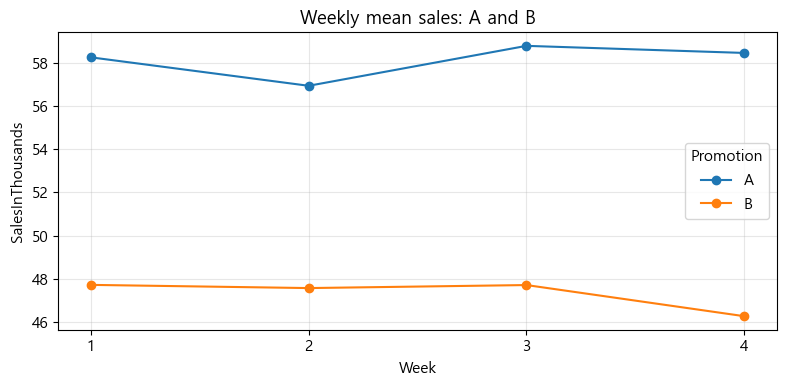

기록상 여러 Promotion이 있는 매장 수: 0


In [4]:
weekly_sales = (campaign_ab.groupby(["week", "Promotion"])["SalesInThousands"]
                .mean().unstack("Promotion").sort_index())
# unstack은 Promotion 1·2를 각각 열로 옮겨 두 집단을 나란히 읽게 합니다.
display(weekly_sales.round(3))
weekly_sales.rename(columns={1: "A", 2: "B"}).plot(marker="o", figsize=(8, 4))
plt.title("Weekly mean sales: A and B")
plt.xlabel("Week")
plt.ylabel("SalesInThousands")
plt.xticks([1, 2, 3, 4])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# 원본 전체를 점검하여 Promotion 3으로 바뀐 기록도 놓치지 않습니다.
promotion_kinds = campaign.groupby("LocationID")["Promotion"].nunique()
print("기록상 여러 Promotion이 있는 매장 수:", int((promotion_kinds > 1).sum()))

### 필수 2 · 요구사항 1 — 실제 주차별 차이 해석

In [5]:
weekly_sales['B_minus_A']=weekly_sales[2]-weekly_sales[1]
display(weekly_sales.round(3))

Promotion,1,2,B_minus_A
week,,,
1,58.244,47.730,-10.514
2,56.930,47.583,-9.347
3,58.775,47.722,-11.053
4,58.447,46.283,-12.164


1주차 B−A는 -10.514, 4주차는 -12.164 (천 단위)다. 음수는 B의 평균이 더 낮다는 뜻이다. A/B 우열과 초기 반응의 소멸은 다른 개념이므로 이 추이만으로 신규성 효과의 존재 또는 부재를 확정하지 않는다.

### 필수 2 · 요구사항 2 — 교육용 사례 진단표

| 사례 | 오류·의심 | 근거 | 해석 문제 | 수정·확인 |
|---|---|---|---|---|
| N | 신규성 효과 가능성 | B 60→55→51→50, A 50 유지 | 초기 우위를 장기 효과로 일반화 | 예정 기간 관측, 노출·외부 변화 확인 |
| C | 표본 오염 | 동일 매장이 주마다 A/B 모두 경험 | 교차 경험·잔류 효과 혼합 | 매장별 고정 배정, 실제 적용 기록 확인 |
| E | 조기 종료 | 예정 4주 중 유리한 1주만 보고 중단 | 우연한 변동을 선택 | 사전 기간·표본 조건 준수 |
| S | SRM 의심 | 0.5 배정 계획인데 6500:3500 | 배정/수집 이상 가능성 | 누락·중복·필터·배정 로그 조사 후 성과 해석 |

### 필수 2 · 요구사항 3 — 실제 데이터의 확인 범위

| 오류 | 실제 CSV 확인 사실 | 추가 정보 |
|---|---|---|
| 신규성 | 4주 모두 B 평균이 낮음 | 신규 노출 시점, 더 긴 추이, 외부 요인 |
| 오염 | 원본에서 매장별 Promotion은 한 종류 | 현장 적용·타 프로모션 노출·매장 간 파급 |
| 조기 종료 | 4개 주차가 기록됨 | 사전 일정, 중간 보고, 중단 결정 기록 |
| SRM | A 43, B 47개 매장 | 예정 배정 확률·모집 규모·수집 누락 |

교육용 사례 N/C/E/S가 실제 WA에서 발생했다고 결론 내리지 않는다.

### 필수 2 · 요구사항 4 — Q&A

Q1. 최종 우열이 같아도 결과를 보고 임의 종료한 설계 문제는 사라지지 않는다. 사전 종료 기준을 지켜야 한다.

Q2. 아니다. CSV 라벨이 하나인 것만 확인했다. 현장의 다른 경험, 잘못된 적용, 집단 간 영향은 별도 점검해야 한다.

---
## 과제 1. 교안 개념으로 보고서를 고치고 적용 여부 판단하기

<aside>
A를 기존안, B를 변경안으로 가정합니다. 실제 매출을 비교하고 잘못된 보고서를 고친 뒤, 교안의 실험 설계 요소와 결과 해석 원칙으로 다음 행동을 제시하세요.
과제 1(문제 3-1)만 제출·채점 대상입니다.
</aside>

### 문제 3-1. 프로모션 분석 검토 보고서

**잘못된 보고서 초안 — 수정 대상**
1. “A 172개·B 188개 매장을 확보했으므로 필요한 표본 수를 충족했다.”
2. “두 집단의 매장 수가 비슷하므로 무작위 배정이 정상적으로 이루어졌음이 증명되었다.”
3. “1주차에 A가 높았고 4주에도 같으니 1주차 결과만 보고 종료해도 문제가 없다.”
4. “B가 모든 주에서 A보다 낮으므로 신규성 효과는 없다고 확인했다.”
5. “현재 평균에서 B가 낮으므로 다른 조건을 확인할 필요 없이 B는 앞으로도 영구 폐기한다.”

**요구사항**
1. 제공된 `location_sales`로 집단별 평균을 계산하고 `B−A`를 출력하세요. A/B 값·차이·단위를 제시하여 관측 성과를 해석하세요. 이번 강의에서는 유의성 검정이나 인과 효과 확정을 요구하지 않습니다.
2. 초안 1~5번을 각각 **수정 문장 / 실제 수치 또는 교안 근거**로 고치세요. 오류 지적만 하지 말고 보고서에 사용할 수 있는 문장으로 작성합니다.
3. 아래 **교육용 후속 실험 결과**를 보고 B를 바로 전면 적용할지 판단하세요. 핵심 지표 변화·보조 지표 변화·추가 확인을 포함합니다. 주어진 값을 읽어 판단하면 되며 지표 계산식 설계는 요구하지 않습니다.
4. 다음에 실시할 실험의 설계 4대 요소를 표로 작성하세요. 아래 **제공된 계획 조건**을 사용하고 각 요소의 이유를 한 줄씩 설명합니다. 무작위 배정 고정 방식과 중간 결과가 좋을 때의 처리도 덧붙입니다.
5. **실제 WA 결과**에 대한 최종 권고를 4~6문장으로 작성하세요. B 전환 여부·수치 근거·확인하지 못한 실험 조건·다음 확인 행동을 포함하고 Q1·Q2에 답하세요. 요구사항 3의 교육용 수치를 실제 WA 결과에 섞지 않습니다.

### 요구사항 3: 교육용 후속 실험 — WA 실제 결과 아님

| 항목 | A | B |
|---|---:|---:|
| 핵심 지표: 매장별 평균 주간 매출(천 단위) | 50 | 55 |
| 중요한 보조 지표: 환불률 | 2% | 5% |

이 후속 실험은 계획된 기간과 표본 수를 충족했고, 매출 차이는 통계적으로 유의하다는 결과가 제공되었다고 가정합니다. 직접 검정하지 않습니다. 환불률 악화를 어느 정도까지 허용할지는 아직 검토되지 않았고, 배정·수집·실제 적용 점검 결과는 제공되지 않았습니다.

### 요구사항 4: 다음 실험의 제공된 계획 조건 — 새 계획용 가정
- 기존 A와 변경 B의 매출을 비교한다.
- 매장을 기준으로 각각 A/B에 0.5 확률로 한 번 배정하고, 같은 매장은 실험 내내 같은 프로모션을 사용한다.
- 모든 참여 매장이 같은 시점부터 4주간 관측되도록 시작 전에 일정을 확정한다.
- 핵심 지표는 매장별 4주 평균 주간 매출의 집단 평균이다.
- **목표 표본 크기는 실험 전에 별도 담당자가 산정하여 확정한 전체 100개 매장으로 주어진다.** 산정 방법은 이번 강의 범위가 아니며, 100개를 학생이 계산하거나 충분성을 증명할 필요는 없다.
- 계획한 100개 매장을 확보하고 각 매장의 4주 관측을 완료한다. 중간 매출이 좋아 보인다는 이유로 임의 종료하지 않는다.

**확인 포인트 — 요구사항과 1:1 대응**
1. 제공된 매장 단위 평균을 집단별로 비교하고 단위·관측 차이를 정확히 설명했는가?
2. 초안 다섯 문장을 모두 실제 근거와 교안 원리에 맞게 수정했는가?
3. 교육용 핵심·보조 지표를 함께 읽고 실험 조건까지 확인하도록 제안했는가?
4. 제공 조건으로 설계 4대 요소와 이유를 쓰고 배정·종료 원칙을 유지했는가?
5. 실제 WA 근거만으로 권고를 작성하고 Q1·Q2에 답했는가?

**Q&A**
- Q1. 교육용 후속 실험에서 매출 차이가 통계적으로 유의하다고 주어졌는데도 다른 조건을 확인해야 하는 이유는 무엇인가요?
- Q2. 다음 실험에서 전체 100개 매장을 0.5 확률로 배정했는데 53:47로 나뉘었다면, 정확히 50:50으로 맞추기 위해 배정된 매장을 옮겨야 하나요?

### 과제 1 · 요구사항 1 — 실제 매장 단위 평균 비교

In [6]:
group_sales=location_sales.groupby('Promotion').four_week_mean_sales.mean()
display(group_sales.rename('매장별 4주 평균 주간 매출의 집단 평균'))
sales_diff=group_sales.loc[2]-group_sales.loc[1]
print(f'B−A: {sales_diff:.3f} (천 단위)')

Promotion
1    58.099012
2    47.329415
Name: 매장별 4주 평균 주간 매출의 집단 평균, dtype: float64

B−A: -10.770 (천 단위)


A 58.099, B 47.329, B−A -10.770 (천 단위)다. 매장별 4주 평균 주간 매출을 집단 평균한 것으로 4주 누적 매출이 아니다. 관측 평균에서 B가 낮지만 인과 효과나 통계적 유의성을 확정하지 않는다.

### 과제 1 · 요구사항 2 — 보고서 다섯 문장 수정

1. “A 172행·B 188행은 각각 43개·47개 매장의 4주 기록이다. 필요한 표본 수 충족 여부는 사전 목표를 확인해야 한다.” 반복 행을 매장으로 세면 안 된다.
2. “집단 수가 비슷하지만 무작위 배정은 확인되지 않았다. 배정 절차와 로그를 점검한다.” 균형은 절차의 증명이 아니다.
3. “1주와 4주 모두 A가 높았더라도 결과를 보고 1주차에 중단하는 것은 정당화되지 않는다.” 사전 종료 기준이 필요하다.
4. “B가 모든 주에서 낮다는 사실만으로 신규성 효과가 없다고 결론 내릴 수 없다.” 초기 반응 변화와 집단 간 수준 차이를 구분한다.
5. “현재 기록은 B 전면 도입을 지지하지 않지만 영구 폐기는 단정하지 않는다.” 배정·적용·수집과 개선안을 검토하고 재실험 여부를 결정한다.

### 과제 1 · 요구사항 3 — 핵심 지표와 보조 지표 함께 판단

교육용 후속 실험에서는 매출이 50→55로 10% 증가했지만 환불률도 2%→5%로 3%p 악화됐다. 통계적으로 유의한 매출 증가가 주어져도 바로 전면 적용하지 않는다. 환불 악화 허용 기준과 고객 영향을 검토하고 배정·수집·실제 적용 점검을 완료한 뒤 판단한다. 이 수치는 실제 WA 결과가 아니다.

### 과제 1 · 요구사항 4 — 제공 조건으로 설계 4대 요소 작성

| 요소 | 다음 실험 계획 | 이유 |
|---|---|---|
| 비교 집단 | 매장 단위 A 기존/B 변경, 각 0.5 확률로 한 번 고정 배정 | 선택 편향과 교차 경험 방지 |
| 기간 | 모든 매장이 같은 시점부터 4주 | 관찰 기회·계절 조건 통일 |
| 핵심 지표 | 매장별 4주 평균 주간 매출의 집단 평균 | 매장을 동일 가중치로 비교 |
| 표본 크기 | 사전 담당자가 확정한 전체 100개 매장 | 결과에 맞춘 표본 변경 방지 |

100개 매장을 확보하고 각각 4주를 완료한다. 중간 매출이 좋아도 임의 종료하지 않고, 배정은 실험 내내 유지한다. 100개의 충분성을 이 실습에서 새로 증명한 것은 아니다.

### 과제 1 · 요구사항 5 — 실제 WA 최종 권고와 Q&A

현재 WA 기록만으로 B로 전면 전환하지 않을 것을 권고한다. 매장 단위 평균은 A 58.099, B 47.329로 B가 10.770 천 단위 낮다. 실제 무작위 배정 절차, 예정 기간, 목표 표본 수와 배정 비율은 확인되지 않았다. 배정 로그와 매장별 실제 적용, 수집 누락을 먼저 점검해야 한다. 이후 개선된 B를 사전에 정한 4주·100개 매장 계획으로 검증할 수 있다.

**Q1.** 통계적 유의성은 환불 악화의 수용 가능성이나 배정·수집의 정상성을 대신하지 않는다.

**Q2.** 53:47은 확률 배정에서 가능한 결과이며 정확히 맞추려고 매장을 옮기지 않는다. 사전 배정 절차 준수 여부를 확인한다.

---
## 제출 안내 및 마무리
- **과제 1의 요구사항 1~5와 Q&A만 제출·채점 대상**입니다. 필수 1·2는 연습입니다.
- 과제 실행에 필요한 준비 코드와 재사용한 코드는 제출 노트북에 함께 포함합니다.
- 요구사항 번호별로 답안을 작성하고 코드 실행 결과를 남깁니다.
- 실제 WA 결과, 교육용 사례, 다음 실험 계획을 구분합니다.
- 검토 순서: **무엇을 비교했는가 → 설계 조건이 무엇인가 → 어떤 오류를 의심하는가 → 숫자가 무엇을 보여주는가 → 추가 확인 후 무엇을 결정할 것인가**.

### 교안과 문제의 연결

| 교안 | 적용 위치 |
|---|---|
| 1. A/B 핵심 메커니즘 | 필수 1 요구사항 1·3·4, 과제 1 요구사항 2·4·5 |
| 2. 설계 4대 요소 | 필수 1 요구사항 2·4, 과제 1 요구사항 4 |
| 3. 설계 오류 네 가지 | 필수 2 전체, 과제 1 요구사항 2·5 |
| 4. 결과 해석 시 주의점 | 과제 1 요구사항 1·3·5 |